# Numerically solving the Schrodinger equation

In this assignment you will use [<tt>qmsolve</tt>](https://github.com/quantum-visualizations/qmsolve) to solve the time-independent Schrodinger equation in one dimension and plot the solutions.

### First, install <tt>qmsolve</tt> in one of two ways:
<ul>
    <li>From a <tt>unix</tt> command line, type <tt>pip install qmsolve</tt></li>
    <li>Put the following commands in a code cell in this notebook and execute:<br />
        <tt>import sys</tt><br />
        <tt>!{sys.executable} -m pip install qmsolve</tt></li>
</ul>

### Homework problems:

<ol start=0>
    <li>Follow the link to the <tt>qmsolve</tt> GitHub page above. Click the link for the <tt>examples</tt> folder, then click on the <tt>eigenstate solver examples</tt> folder. Finally, click on <tt>1D_harmonic_oscillator.py</tt> to see a short code snippet that will calculate wavefunctions for a simple harmonic oscillator (SHO).</li>
    <li><tt>1D_harmonic_oscillator.py</tt> imports the <tt>Hamiltonian</tt> class from <tt>qmsolve</tt>. In quantum mechanics, what is a Hamiltonian? Please use multiple sources to formulate your answer and cite those sources. For this problem, crowd-sourced references such as Wikipedia and stackexchange are acceptable.</li>
    <li>Which force law is defined in the function <tt>harmonic_oscillator()</tt> in cell 2 of this notebook?</li>
    <li>What are the eigenstates referred to in lines 22 and 23 in <tt>1D_harmonic_oscillator.py</tt>? Again, please use multiple sources to formulate your answer and cite those sources.
    <li>Code cells 1 and 2 below contain imported code from <tt>1D_harmonic_oscillator.py</tt>, including a visualization of eigenstate 0 of the SHO. In subsequent code cells, plot any five SHO eigenstates of your choice.</li>
</ol>

Note: you can write your answers to the non-code problems in a markdown cell. From within a new notebook cell, click the box with the downward-pointing arrow that says "Code" (on your Jupyter toolbar) and change to "Markdown". Then you can just type in the cell like a regular text file.

In [ ]:
1. #The Hamiltonian of a system is a term referenced frequently in the realm of quantum mechanics that refers to the total energy contained 
#within that system, including both its kinetic and potential energy. 
#https://en.wikipedia.org/wiki/Hamiltonian_(quantum_mechanics)   
#https://www.math.umd.edu/~immortal/MATH246/lecturenotes/ch3-7.pdf

2. #Hookes Law

3. #The eigenstates are the permitted stationary states of a quantum system. Solving the Hamiltonian through the 
   #Schrödinger equation yields specific discrete energy levels, known as eigenvalues, along with their associated wave functions, 
   #called eigenstates. Each eigenstate corresponds to a unique, well-defined energy. In the case of the harmonic oscillator, these 
   #eigenstates represent the quantized vibrational modes of the system. Eigenstates are important because a measurement of the 
   #particle’s energy in one of these states will always produce the same definite energy value.
   #https://en.wikipedia.org/wiki/Eigenvalues_and_eigenvectors, https://phys.libretexts.org/Bookshelves/Quantum_Mechanics/Introductory_Quantum_Mechanics_(Fitzpatrick)/03%3A_Fundamentals_of_Quantum_Mechanics/3.08%3A_Eigenstates_and_Eigenvalues

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qmsolve import Hamiltonian, SingleParticle, init_visualization, Å, eV

Computing...
Took 0.059760093688964844
[ 13.8243627   41.46350403  69.08346722  96.68423227 124.26577906
 151.82808744 179.37113718 206.89490796 234.39937942 261.8845311
 289.35034249 316.79679298 344.22386192 371.63152856 399.01977209
 426.38857162 453.73790619 481.06775475 508.3780962  535.66890934
 562.9401729  590.19186555 617.42396585 644.63645231 671.82930335
 699.00249732 726.15601246 753.28982697 780.40391895 807.49826642]


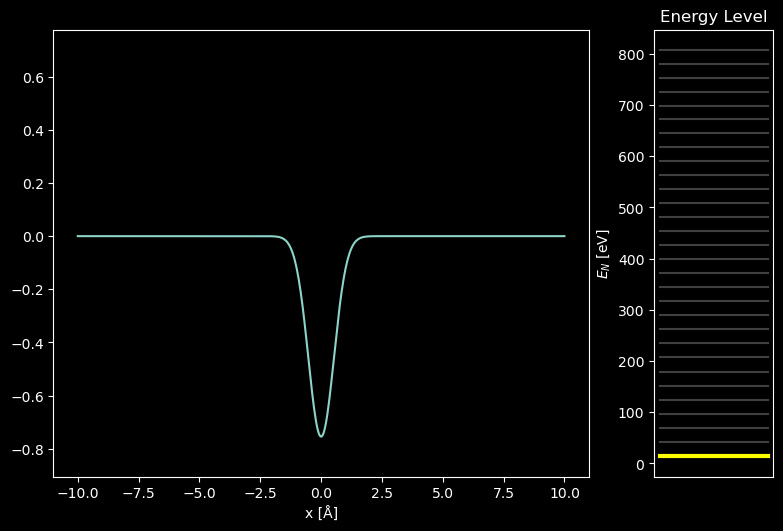

In [2]:
# Harmonic oscillator potential
def harmonic_oscillator(particle):
    k = 100 * eV / Å**2
    return 0.5 * k * particle.x**2

# Define the Hamiltonian
H = Hamiltonian(particles = SingleParticle(), potential = harmonic_oscillator, 
                spatial_ndim = 1, N = 512, extent = 20*Å)

#Diagonalize the Hamiltonian and compute the eigenstates
eigenstates = H.solve(max_states = 30)

# Print out the energies of the eigenstates
print(eigenstates.energies) # the printed energies are expressed in eV

# Visualize the Eigenstates
visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(0)

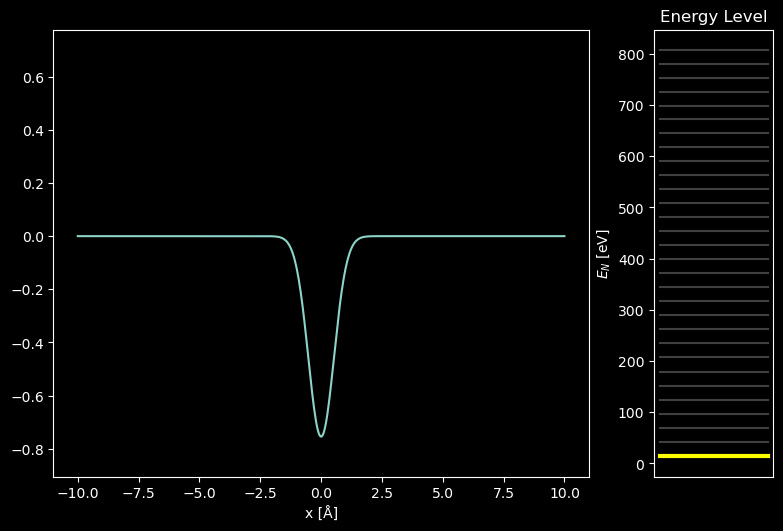

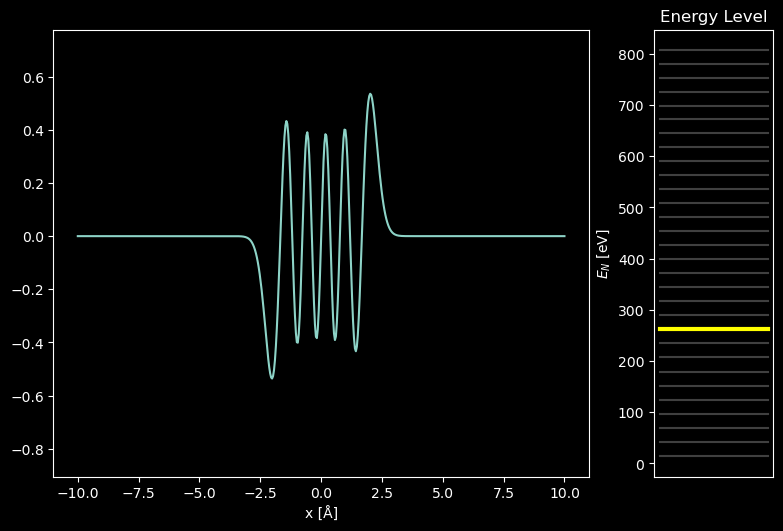

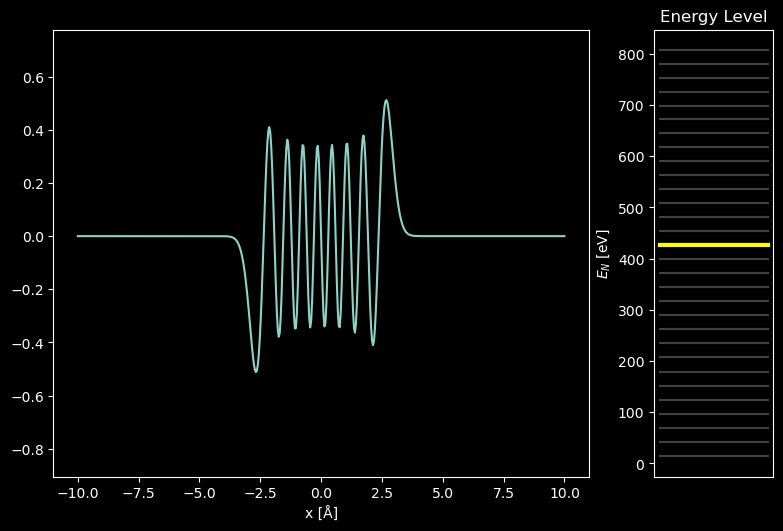

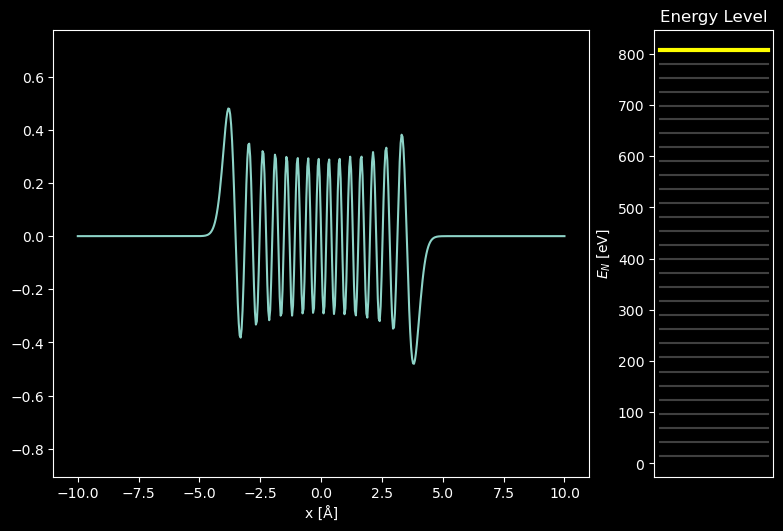

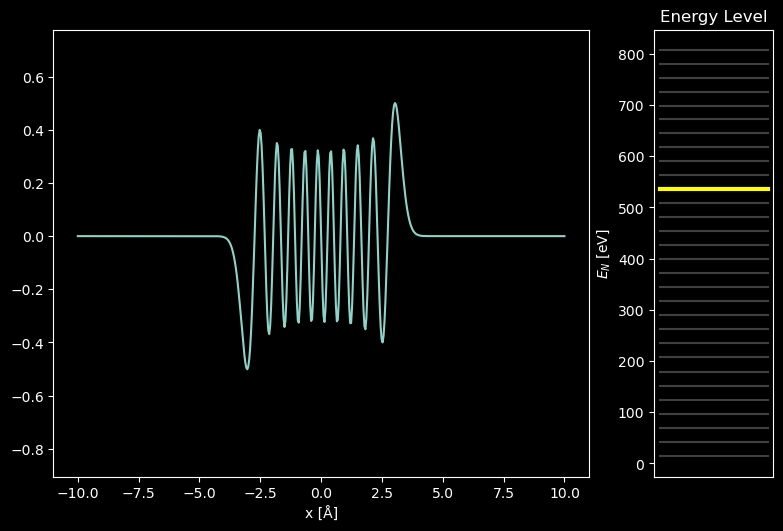

In [3]:
visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(0)
visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(9)
visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(15)
visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(29)
visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(19)

<ol start=5>
    <li>What is on the x-axis of your plots?</li>
    <li>Are your plots showing wave functions $\psi(x)$ or probability functions $\psi^*(x) \psi(x)$? How do you know?</li>
</ol>

### New potential: infinite square well

Below I define the infinite square well potential for $L = 8$ Angstroms and plot the two lowest-energy eigenstates (compare to Figure 6.3 in your textbook).

In [ ]:
#5. It is the displacement of the alpha particle in angstroms.
#6. the wave functions, as it goes below 0, which cannot exist for the probability functions, as the probability density can never be
    #negative.

Computing...
Took 0.05964994430541992
[  0.58926935   2.35704264   5.30321556   9.4276143   14.7299955
  21.21004635  28.8673845   37.70155819  47.71204619  58.89825789
  71.2595333   84.79514311  99.50428872 115.3861023  132.43964681
 150.6639161  170.05783494 190.6202591  212.34997539 235.24570176
 259.30608737 284.52971266 310.91508944 338.46066097 367.16480207
 397.0258192  428.04195057 460.21136622 493.53216816 528.00239048]


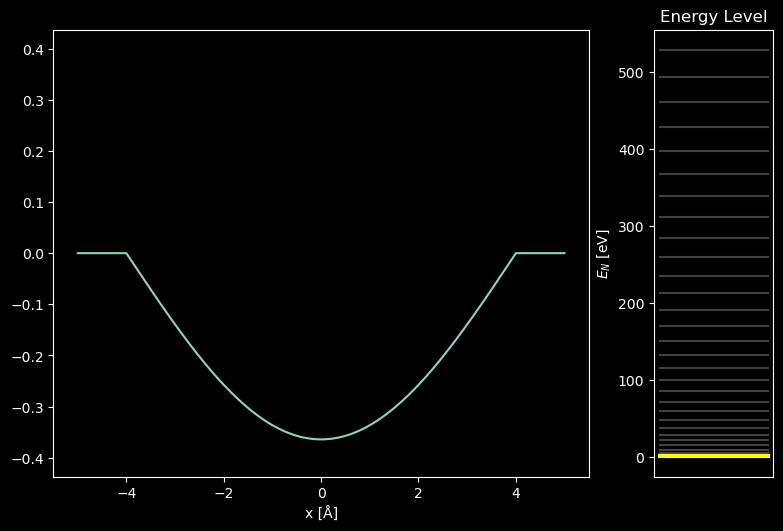

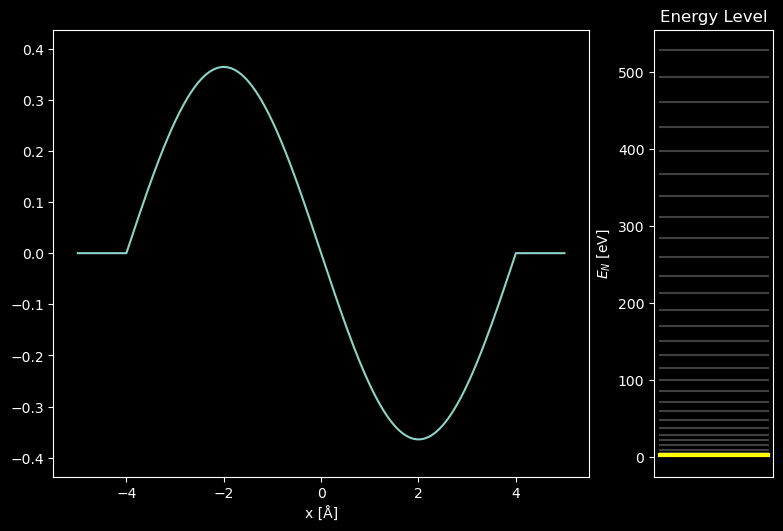

In [5]:
# 8 angstrom-wide infinite square well
def infinite_square_well(particle):
    potential = np.zeros_like(particle.x)
    out_of_bounds = np.abs(particle.x) > 4*Å
    potential[out_of_bounds] = np.inf
    return potential

# Define the Hamiltonian of the infinite square well
H_sw = Hamiltonian(particles = SingleParticle(), potential = infinite_square_well, 
                   spatial_ndim = 1, N = 512, extent = 10*Å)

# Diagonalize the Hamiltonian and compute the eigenstates
eigenstates_sw = H_sw.solve(max_states = 30)

print(eigenstates_sw.energies)

# Visualize the infinite square well eigenstates
visualization_sw = init_visualization(eigenstates_sw)
visualization_sw.plot_eigenstate(0)
visualization_sw.plot_eigenstate(1)

<ol start=7>
    <li>Plot any three infinite square well eigenstates of your choice.</li>
    <li>What property do the infinite square well eigenstates have that's different than the SHO eigenstates? (Hint: think about the properties of valid wave functions we discussed in class)</li>
    <li>What is the relationship between the number of extrema (maxima plus minima) in each eigenstate plot and the quantum number of the eigenstate?</li>
</ol>

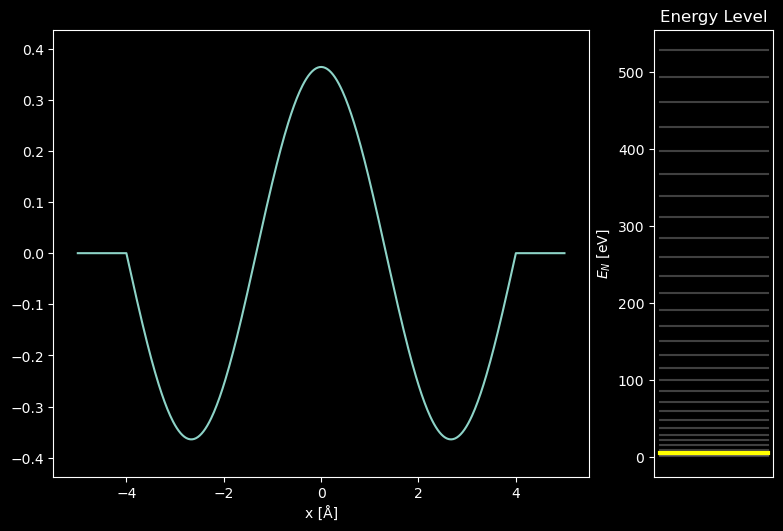

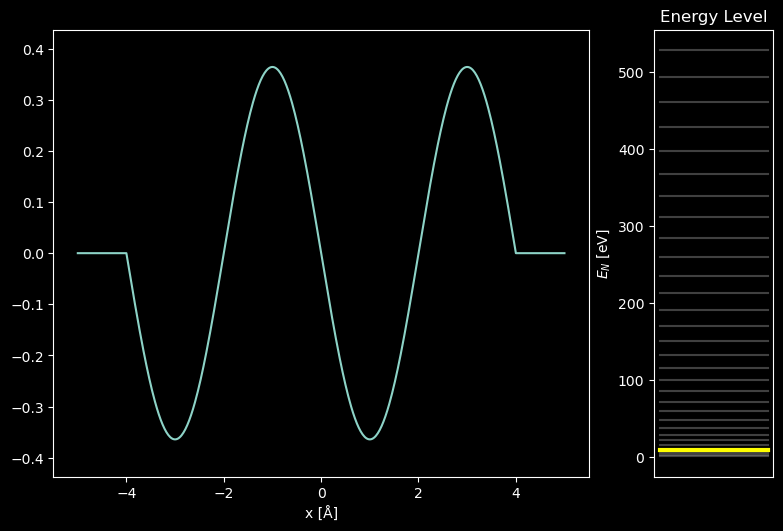

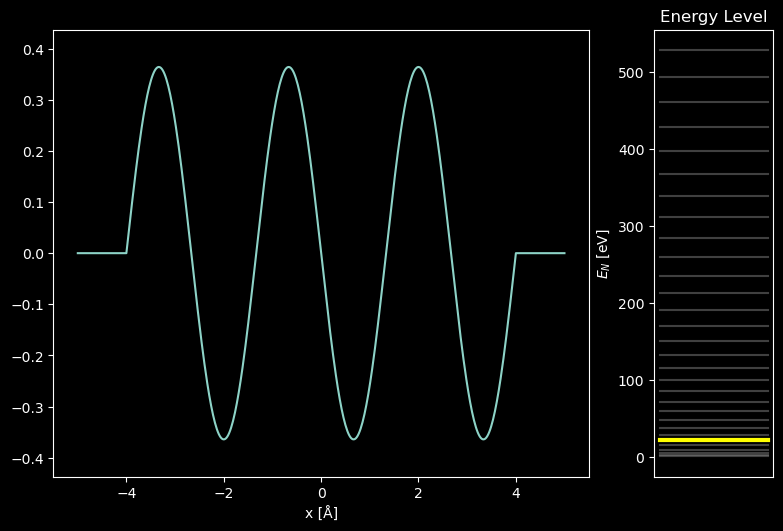

In [6]:
visualization_sw.plot_eigenstate(2)
visualization_sw.plot_eigenstate(3)
visualization_sw.plot_eigenstate(5)

In [ ]:
# 8. The infinite square wells have eigenstates that are equal to 0
# 9. It is a linear relationship, in which one can generalize by setting them equal. When n = 1, #_extrema = 1
#    , when n = 2, #_extrema = 2, etc.

### Now it's your turn to define a potential

<ol start=10>
    <li>Write a function that defines a <em>finite square-well</em> potential (textbook section 5.4). You can choose the width of the well in Angstroms and the potential at the walls in eV. Calculate the finite square-well Hamiltonian and plot any five eigenstates you choose.</li>
    <li>Based on your plots, do you think a particle can get out of the finite square-well potential no matter its quantum number $n$?</li>
</ol>

Computing...
Took 0.10202598571777344


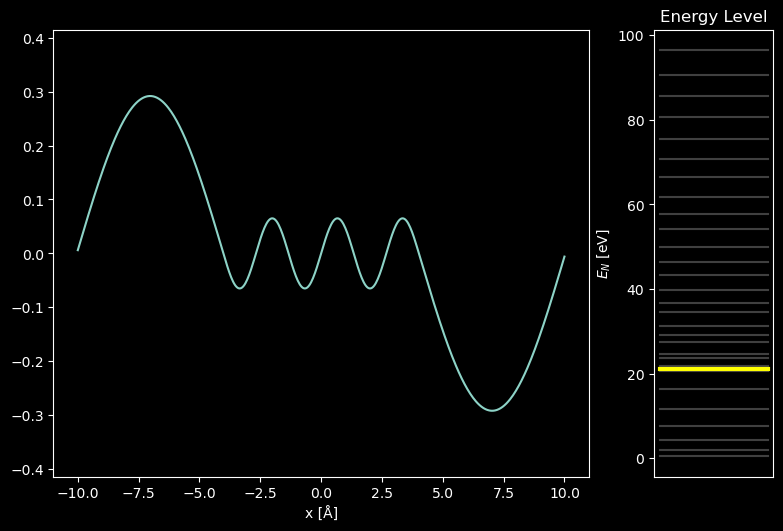

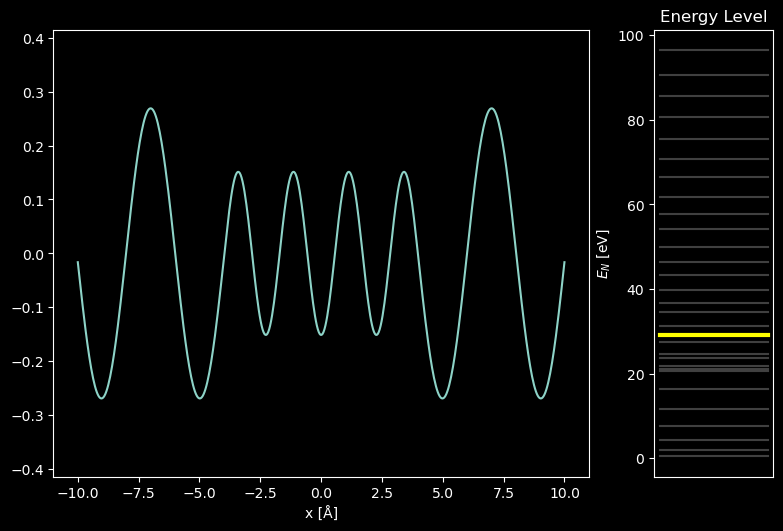

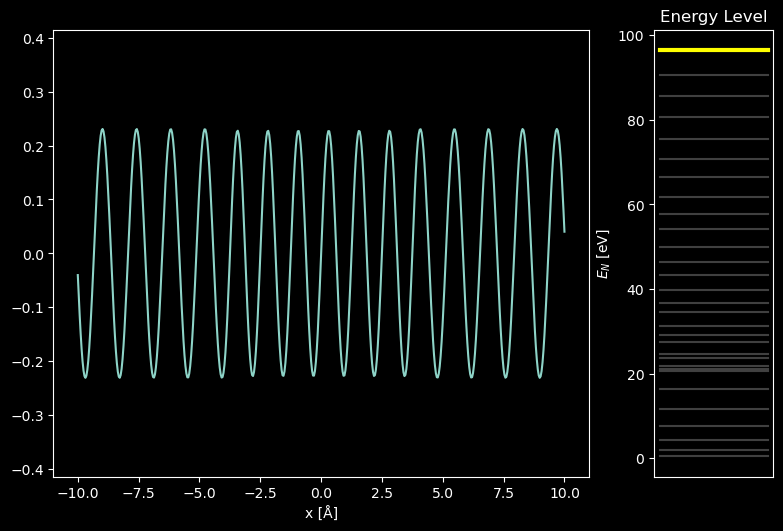

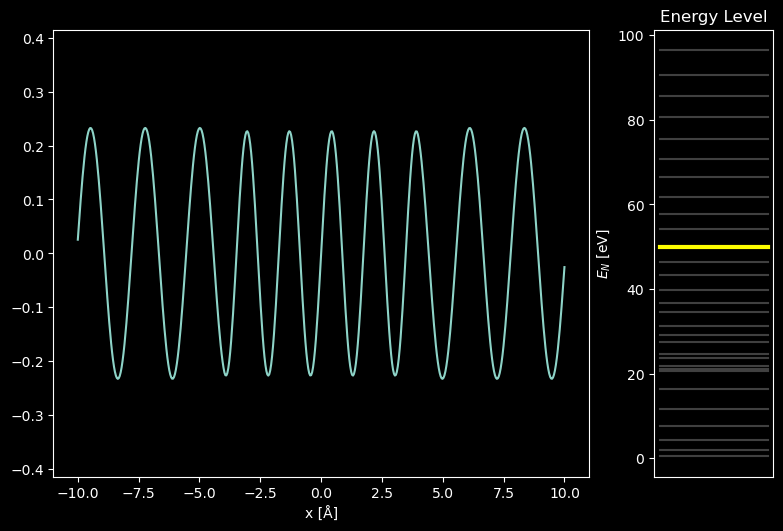

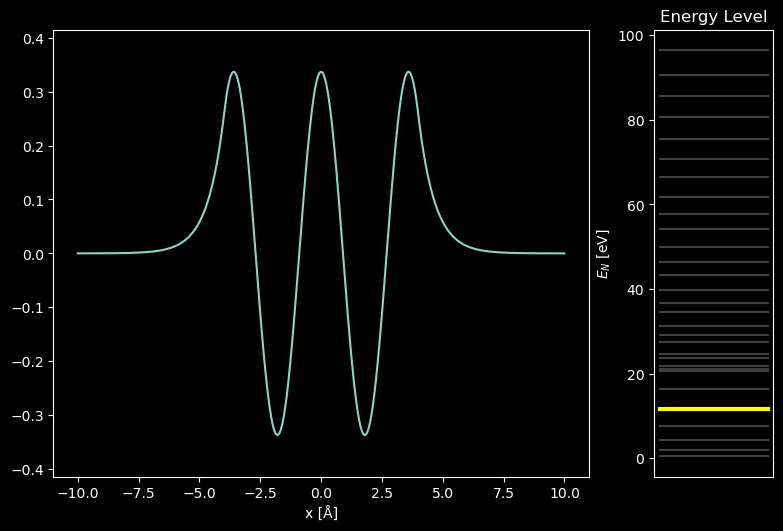

In [11]:
def finite_square_well(particle):
    V0 = 20 * eV
    width = 8 * Å
    potential = np.full_like(particle.x, V0)
    inside = np.abs(particle.x) < width/2
    potential[inside] = 0
    return potential

Hamil_f = Hamiltonian(
    particles = SingleParticle(),
    potential = finite_square_well,
    spatial_ndim = 1,
    N = 512,
    extent = 20*Å)
f_state = Hamil_f.solve(max_states = 30)
vis_f = init_visualization(f_state)

vis_f.plot_eigenstate(7)
vis_f.plot_eigenstate(12)
vis_f.plot_eigenstate(29)
vis_f.plot_eigenstate(19)
vis_f.plot_eigenstate(4)




In [ ]:
#11. Yes. In contrast to the infinite square well, a finite square well has barriers of limited height rather than infinitely large walls. 
#As a result, the wave functions do not drop abruptly to zero at the boundaries but instead penetrate slightly into the classically 
#forbidden regions outside the well. Consequently, there is always a nonzero probability of locating the particle outside the well.
